In [1]:
#DATASET
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetes.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "imtkaggleteam/diabetes",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display(df.head())
print("Rows:", df.shape[0], " | Columns:", df.shape[1])

100%|██████████| 36.2k/36.2k [00:00<00:00, 34.3MB/s]


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


Rows: 403  | Columns: 19


In [2]:
target_source = "glyhb"
drop_cols = ["id", "glyhb"]
features = [c for c in df.columns if c not in drop_cols]

print("Target: diabetic = (glyhb >= 6.5)  -> 1 = diabetic, 0 = not diabetic")
print(f"\nInput features ({len(features)}):")
print(features)

Target: diabetic = (glyhb >= 6.5)  -> 1 = diabetic, 0 = not diabetic

Input features (17):
['chol', 'stab.glu', 'hdl', 'ratio', 'location', 'age', 'gender', 'height', 'weight', 'frame', 'bp.1s', 'bp.1d', 'bp.2s', 'bp.2d', 'waist', 'hip', 'time.ppn']


id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64


,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


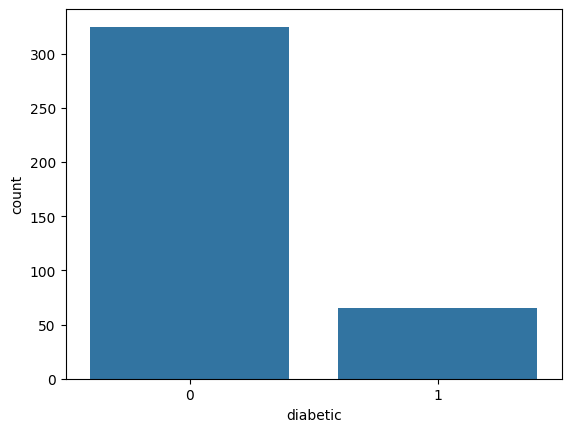

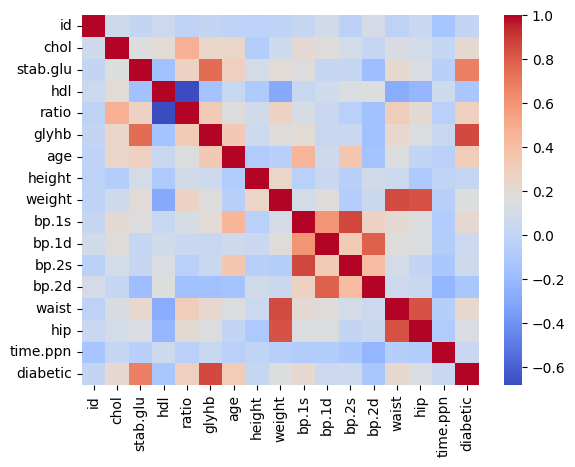

In [3]:
# DATA EXPLORATION
import matplotlib.pyplot as plt
import seaborn as sns

print(df.isnull().sum())
display(df.describe())

df = df.dropna(subset=["glyhb"]).copy()
df["diabetic"] = (df["glyhb"] >= 6.5).astype(int)

sns.countplot(x="diabetic", data=df); plt.show()
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm"); plt.show()

In [6]:
#DATA PREPROCESSING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.select_dtypes("number").drop(columns=["id", "glyhb", "diabetic", "bp.2s", "bp.2d"])
y = df["diabetic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_test = X_test.fillna(X_train.median())
X_train = X_train.fillna(X_train.median())

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
#BUILDING THE NEURAL NETWORK

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#TRAIN THE MODEL

history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=16)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9679 - loss: 0.0716 - val_accuracy: 0.8730 - val_loss: 0.4270
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9679 - loss: 0.0712 - val_accuracy: 0.8730 - val_loss: 0.4241
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9679 - loss: 0.0706 - val_accuracy: 0.8730 - val_loss: 0.4273
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9679 - loss: 0.0699 - val_accuracy: 0.8730 - val_loss: 0.4319
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9679 - loss: 0.0690 - val_accuracy: 0.8730 - val_loss: 0.4353
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9679 - loss: 0.0684 - val_accuracy: 0.8730 - val_loss: 0.4363
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9679 - loss: 0.0678 - val_accuracy: 0.8730 - val_loss: 0.4394
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9679 - loss: 0.0674 - val_accuracy: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8205 - loss: 1.1581
Test accuracy: 0.8205128312110901


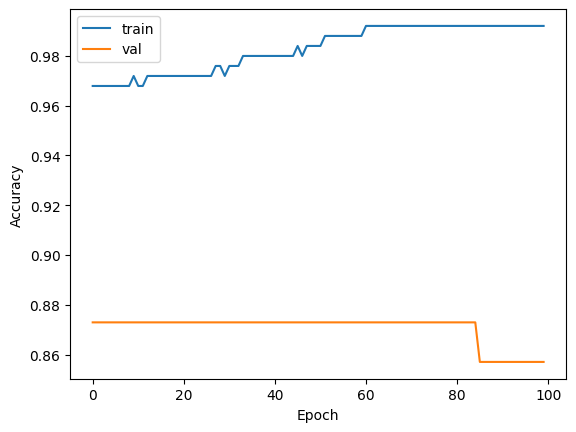

In [10]:
# RESULTS AND DISCUSSION

loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

CONCLUSION:

Performance: The network reached 85.9% test accuracy, about the same as the ~85% majority-class baseline, so recall on the diabetic class () matters more than accuracy. The test loss of 0.82 is high, which suggests the model is overconfident and overfits.

Features used: chol, stab.glu, hdl, ratio, age, height, weight, bp.1s, bp.1d, waist, hip and time.ppn, with the target built from glyhb >= 6.5.

Challenges: Small dataset (390 rows), class imbalance (15% diabetic), and missing values that I filled with the training-set median.

Improvements: Use class weights, add dropout or early stopping, tune layers and neurons, include the categorical columns, and use cross-validation.